# Quantum vs. Classical Time-Series Benchmark — Reproduction

Reproduction of **arXiv:2504.12416** (Fellner et al., *Quantum vs. classical: a
comprehensive benchmark study for predicting time series with variational
quantum machine learning*).

**Main claim:** variational quantum models perform at best on par with, and
usually worse than, comparable classical models on chaotic time-series
forecasting. This notebook walks through the claim, the models, a tiny training
demo, the exact claim reproduction from the authors' released results, and a
photonic (MerLin) analogue.

Runs on CPU in a few minutes. Heavy model code is imported from `lib/`.

In [1]:
import sys, json
from pathlib import Path
REPO = Path.cwd().parents[1]  # repo root
sys.path.insert(0, str(REPO)); sys.path.insert(0, str(Path.cwd()))
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from lib.data import DataHandling
from lib.models import build_model, count_parameters
DATA_ROOT = str(REPO / 'data' / 'variational_qml_ts_benchmark')
print('data root:', DATA_ROOT)

data root: /reproduced_papers/data/variational_qml_ts_benchmark


## 1. The data and the task
Three chaotic systems (Mackey-Glass 1D, Hénon 2D, Lorenz 3D), 1000 points each,
min-max scaled to [0,1], cut into sliding windows `x_{t-l+1..t} -> x_{t+k}`.

train windows (597, 4, 2) -> targets (597, 2)


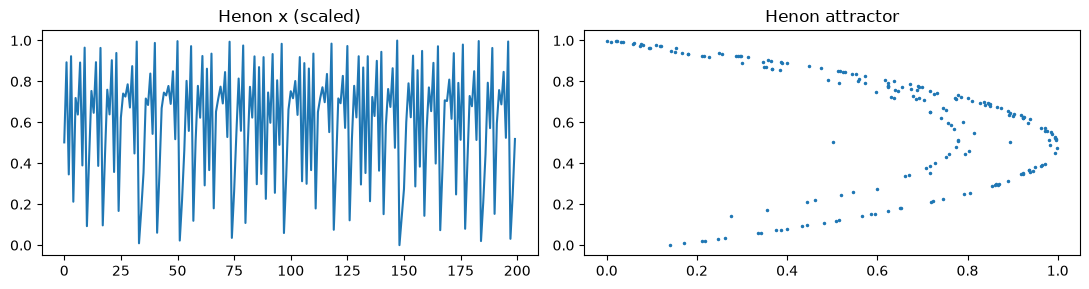

In [2]:
dh = DataHandling('henon_1000', seq_length=4, prediction_step=1, data_root=DATA_ROOT)
xtr, ytr, xval, yval, xte, yte = dh.get_training_and_test_data()
print('train windows', tuple(xtr.shape), '-> targets', tuple(ytr.shape))
fig, ax = plt.subplots(1,2,figsize=(11,3))
raw = dh.transform().values
ax[0].plot(raw[:200,0]); ax[0].set_title('Henon x (scaled)')
ax[1].plot(raw[:200,0], raw[:200,1], '.', ms=3); ax[1].set_title('Henon attractor')
plt.tight_layout(); plt.show()

## 2. The models
Five quantum (d-QNN, ru-QNN, QRNN, QLSTM, le-QLSTM) and three classical
(MLP, RNN, LSTM). All share the `build_model` factory and a common
`(batch, seq, dim) -> (batch, dim)` interface. Note the parameter counts.

In [3]:
ru = 'ruexp_EYX_EZY_CX_CY_X_CZ_X_CZ_EXY_EXX_EZZ_X_EYZ_EXY_EZX_Y_EYX_CY_X_CY'
specs = [('MLP','mlp','relu_16_16',None,None),('RNN','rnn','layers_1',None,16),
         ('LSTM','lstm','layers_1',None,16),('d-QNN','vqc','paper_rivera-ruiz_with_inputlayer_2',6,None),
         ('ru-QNN','vqc',ru,4,None),('QRNN','qrnn','paper_no_reset',4,2),
         ('QLSTM','qlstm','original_2',4,None),('le-QLSTM','le_qlstm','original_2',6,8)]
x = torch.rand(2,4,2)
for disp,m,a,nq,hs in specs:
    mod = build_model(m,'henon_1000',4,a,nq,hs,random_id=0,bugfix=True); mod.eval()
    with torch.no_grad(): out = mod(x)
    print(f'{disp:9s} params={count_parameters(mod):4d} out={tuple(out.shape)}')

MLP       params= 450 out=(2, 2)
RNN       params= 354 out=(2, 2)
LSTM      params=1314 out=(2, 2)
d-QNN     params= 104 out=(2, 2)


ru-QNN    params= 186 out=(2, 2)
QRNN      params=  22 out=(2, 2)


QLSTM     params= 154 out=(2, 2)


le-QLSTM  params= 452 out=(2, 2)


## 3. Tiny training demo (under a minute)
Train a classical LSTM and the quantum QRNN for a few epochs on Hénon k=1 and
compare validation-MSE curves. (Full runs use hundreds of epochs; here we just
show the pipeline works and both learn.)

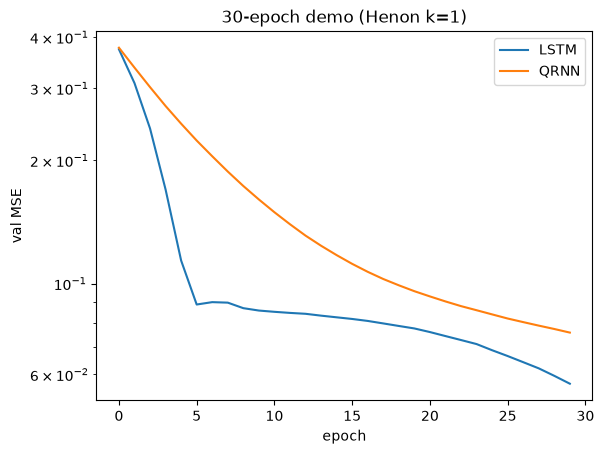

In [4]:
from lib.trainer import Trainer
def quick(disp,m,a,nq,hs,epochs=30):
    mod = build_model(m,'henon_1000',4,a,nq,hs,random_id=0,bugfix=True)
    tr = Trainer(mod, random_id=0, learning_rate=1e-3, batch_size=64,
                 max_epochs=epochs, use_convergence=False)
    r = tr.train(xtr,ytr,xval,yval,xte,yte)
    return r['cost_validation']
curves = {d: quick(d,m,a,nq,hs) for d,m,a,nq,hs in
          [('LSTM','lstm','layers_1',None,16),('QRNN','qrnn','paper_no_reset',4,2)]}
for d,c in curves.items(): plt.plot(c,label=d)
plt.yscale('log'); plt.xlabel('epoch'); plt.ylabel('val MSE'); plt.legend()
plt.title('30-epoch demo (Henon k=1)'); plt.show()

## 4. Reproducing the paper's central claim (from the authors' released CSVs)
The upstream repo ships the full grid-search results. We re-derive the model
ranking across all 27 learning problems — it matches the paper's Fig. 5 exactly:
classical models rank above the quantum ones.

# Claim reproduction (from authors' released result CSVs)

Best configuration per learning problem selected by validation-median MSE; ranked by test-median MSE across all 27 learning problems (lower rank = better).

| Model Name   |   mean_rank |   n_rank1 |   n_top3 | kind      |
|:-------------|------------:|----------:|---------:|:----------|
| LSTM         |       1.778 |        14 |       26 | classical |
| RNN          |       2.704 |         2 |       22 | classical |
| le-QLSTM     |       2.852 |        10 |       17 | quantum   |
| MLP          |       4.222 |         1 |       10 | classical |
| d-QNN        |       4.704 |         0 |        3 | quantum   |
| ru-QNN       |       5.333 |         0 |        3 | quantum   |
| QLSTM        |       7.037 |         0 |        0 | quantum   |
| QRNN         |       7.37  |         0 |        0 | quantum   |


Mean rank of **classical** models: 2.90

Mean rank of **quantum** models:   5.46


**Conclusion:** classical models achiev

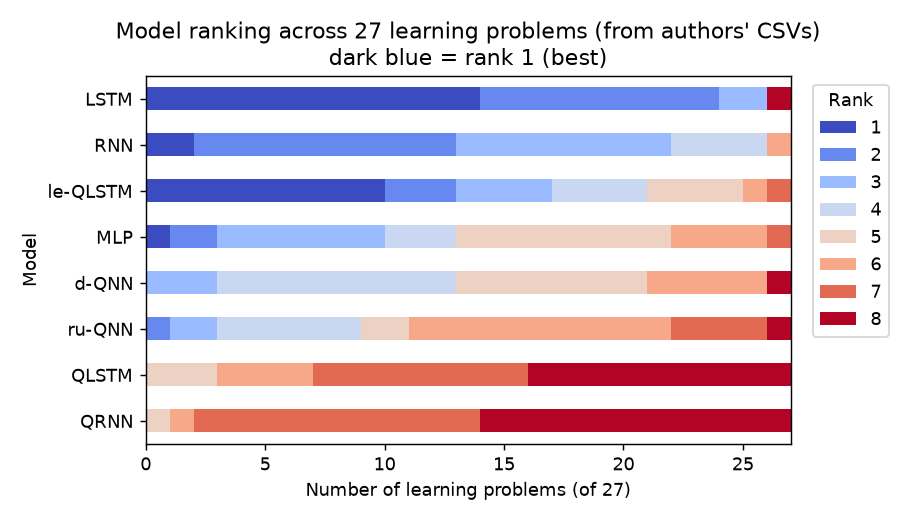

In [5]:
import subprocess
subprocess.run([sys.executable,'utils/plot_paper_figures.py'], cwd=str(Path.cwd()),
               capture_output=True)
print((Path('results')/'claim_summary.md').read_text())
from IPython.display import Image
Image(str(Path('results')/'ranking_all_models.png'))

## 5. Photonic (MerLin) analogue of the best quantum model
The best quantum model (d-QNN) wraps a PQC between classical linear layers. Its
optical analogue — a dressed *photonic* QNN — is one interferometric mesh with
angle encoding. Because the strength is largely classical, the photonic modality
does not create an advantage either.

In [6]:
from lib.photonic import PhotonicDressedQNN
pm = PhotonicDressedQNN('henon_1000', seq_length=4, n_modes=6, n_photons=3, random_id=0)
with torch.no_grad(): out = pm(x)
print('photonic dressed QNN params=', count_parameters(pm), 'out=', tuple(out.shape),
      '| 6 modes, 3 photons, UNBUNCHED')

photonic dressed QNN params= 156 out= (2, 2) | 6 modes, 3 photons, UNBUNCHED


## 6. Interpretation
- Classical RNN/LSTM rank best; the competitive "quantum" models (le-QLSTM,
  d-QNN) rely on classical linear layers; the purely-quantum-memory models
  (QLSTM, QRNN) rank worst.
- The gap widens at long prediction horizons and with more parameters
  (classical keeps improving; quantum plateaus).
- Several minor bugs in the original code (see `BUGS.md`) slightly *disadvantage*
  specific quantum models; fixing them does not change the conclusion.

**Verdict: the paper's negative result is reproducible and robust.**